In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("comtrade_natural_gas_clean.csv")
df.head()




,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,flow,transport,qty_type,alt_qty_type,customs_type
0,2000-01-01,2000,1,757,M,380,H1,271121,C01,3200,...,False,9.745640e+02,False,Switzerland,Italy,Import,Road,kg,Weight in kilograms,Clearance for home use
1,2000-01-01,2000,1,757,M,643,H1,271121,C01,9100,...,False,4.851263e+06,False,Switzerland,Russian Federation,Import,Pipelines and cables,kg,Weight in kilograms,Clearance for home use
2,2000-01-01,2000,1,757,M,528,H1,271121,C01,9100,...,False,8.562759e+06,False,Switzerland,Netherlands,Import,Pipelines and cables,kg,Weight in kilograms,Clearance for home use
3,2000-01-01,2000,1,757,M,380,H1,271121,C01,9100,...,False,1.058566e+06,False,Switzerland,Italy,Import,Pipelines and cables,kg,Weight in kilograms,Clearance for home use
4,2000-01-01,2000,1,757,M,276,H1,271121,C01,9100,...,False,2.030711e+07,False,Switzerland,Germany,Import,Pipelines and cables,kg,Weight in kilograms,Clearance for home use


In [3]:
# Ensuring correct dtypes
df["period"] = pd.to_datetime(df["period"])
df["primaryValue"] = pd.to_numeric(df["primaryValue"], errors="coerce")
df["netWgt"] = pd.to_numeric(df["netWgt"], errors="coerce")

df = df[df["primaryValue"].notna() & (df["primaryValue"] >= 0)]

In [4]:
df["cmdCode"] = df["cmdCode"].astype(str)
df["product"] = np.where(
    df["cmdCode"] == "271111",
    "LNG (271111)",
    "Gaseous NG (271121)"
)

df["product"].value_counts()


product
LNG (271111)           51236
Gaseous NG (271121)    44993
Name: count, dtype: int64

In [5]:
# Data Checks
# print("Rows:", len(df))
# print("Years:", df["refYear"].min(), "-", df["refYear"].max())
# print("Flows:", df["flow"].unique())
# print("isAggregate share:", df["isAggregate"].mean())

df_2010 = df[df["refYear"] >= 2010].copy()
df_2010.head()

# print("Rows after 2010 filter:", len(df_2010))
# print("Years:", df_2010["refYear"].min(), "-", df_2010["refYear"].max())



,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,...,primaryValue,isAggregate,reporter,partner,flow,transport,qty_type,alt_qty_type,customs_type,product
8944,2010-01-01,2010,1,56,X,792,H3,271111,C00,0,...,2.080427e+07,False,Belgium,Turkey,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,LNG (271111)
8945,2010-01-01,2010,1,56,X,826,H3,271121,C00,0,...,9.716870e+07,False,Belgium,United Kingdom,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8946,2010-01-01,2010,1,56,X,276,H3,271121,C00,0,...,1.044149e+07,False,Belgium,Germany,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8947,2010-01-01,2010,1,56,X,528,H3,271121,C00,0,...,7.802086e+07,False,Belgium,Netherlands,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)
8948,2010-01-01,2010,1,56,X,442,H3,271121,C00,0,...,2.272164e+07,False,Belgium,Luxembourg,Export,Total Modes of Transport,kg,Terajoule (gross calorific value),TOTAL CPC,Gaseous NG (271121)


## Global trade evolution (Basic Trend Analysis)

Goal: Establish baseline trends in global natural gas trade.  
We aggregate total imports vs exports and compare LNG vs gaseous gas using annual and **monthly time series.


In [6]:
annual_val = (
    df_2010
    .groupby(["refYear", "flow", "product"], as_index=False)
    .agg(value_usd=("primaryValue", "sum"))
)

annual_val.head()


,refYear,flow,product,value_usd
0,2010,Export,Gaseous NG (271121),7.734047e+10
1,2010,Export,LNG (271111),2.724152e+10
2,2010,Import,Gaseous NG (271121),1.411448e+11
3,2010,Import,LNG (271111),7.064302e+10
4,2011,Export,Gaseous NG (271121),1.056419e+11


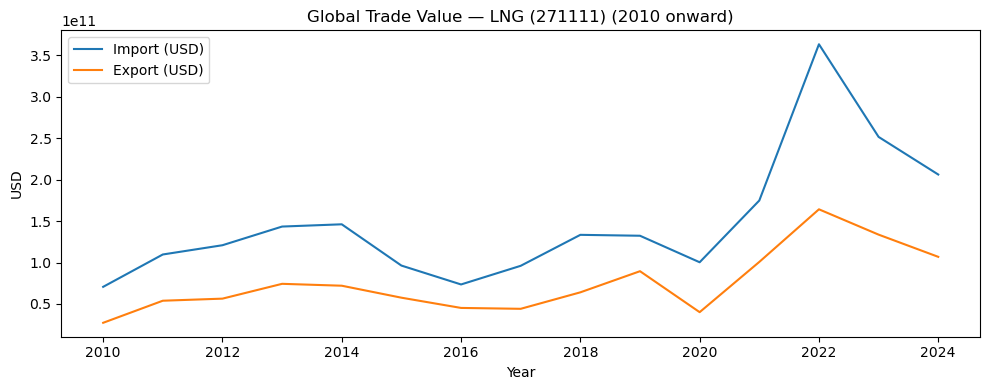

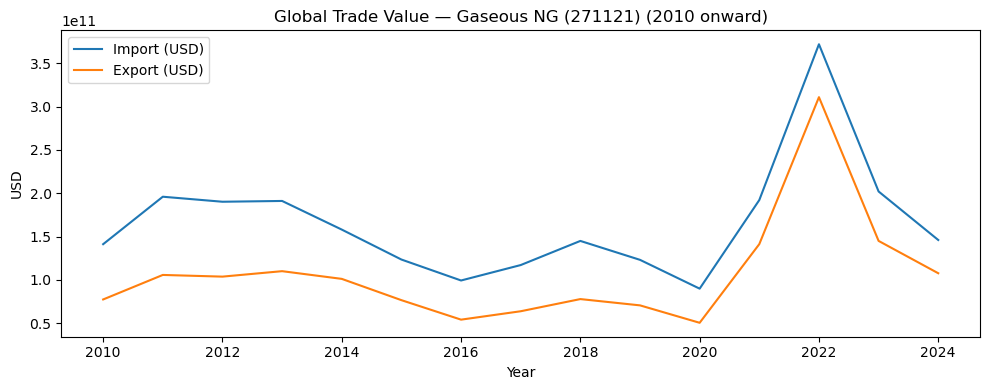

In [7]:
annual_val_piv = (
    annual_val
    .pivot_table(
        index=["refYear", "product"],
        columns="flow",
        values="value_usd",
        fill_value=0
    )
    .reset_index()
)

annual_val_piv["net_trade_usd"] = (
    annual_val_piv.get("Export", 0) - annual_val_piv.get("Import", 0)
)

# annual_val_piv.head()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = annual_val_piv[annual_val_piv["product"] == prod].sort_values("refYear")

    plt.figure(figsize=(10,4))
    plt.plot(tmp["refYear"], tmp["Import"], label="Import (USD)")
    plt.plot(tmp["refYear"], tmp["Export"], label="Export (USD)")
    plt.title(f"Global Trade Value — {prod} (2010 onward)")
    plt.xlabel("Year")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()




In [8]:
df_lng = df_2010[
    (df_2010["product"] == "LNG (271111)") &
    (df_2010["netWgt"].notna()) &
    (df_2010["netWgt"] > 0)
].copy()

print("Rows (LNG with netWgt):", len(df_lng))

df_lng = df_lng[df_lng["isNetWgtEstimated"] == False].copy()

lng_reporter_year = (
    df_lng
    .groupby(["refYear", "flow", "reporterCode", "reporter"], as_index=False)
    .agg(netWgt_kg=("netWgt", "mean"))
)

lng_reporter_year.head()





Rows (LNG with netWgt): 45029


,refYear,flow,reporterCode,reporter,netWgt_kg
0,2010,Export,12,Algeria,2.552279e+08
1,2010,Export,32,Argentina,1.000000e+00
2,2010,Export,51,Armenia,8.000000e-01
3,2010,Export,56,Belgium,5.480876e+07
4,2010,Export,72,Botswana,2.079333e+03


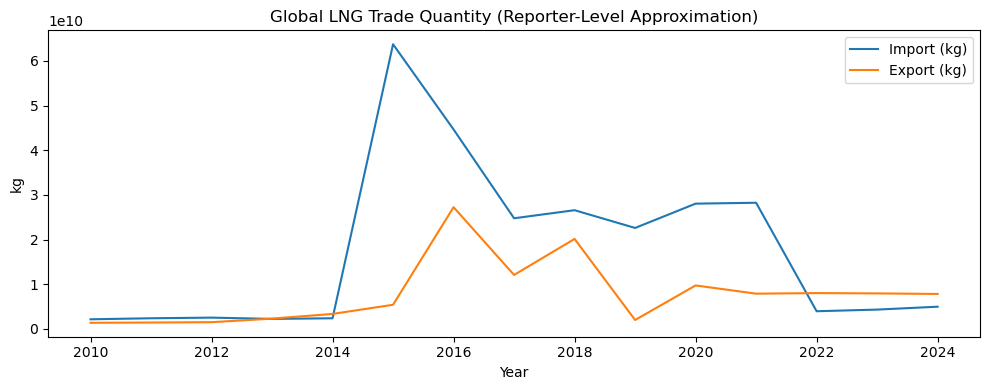

In [9]:
global_lng_qty = (
    lng_reporter_year
    .groupby(["refYear", "flow"], as_index=False)
    .agg(global_netWgt_kg=("netWgt_kg", "sum"))
)

global_lng_qty.head()

global_lng_qty_piv = (
    global_lng_qty
    .pivot_table(
        index="refYear",
        columns="flow",
        values="global_netWgt_kg",
        fill_value=0
    )
    .reset_index()
)

global_lng_qty_piv.head()

plt.figure(figsize=(10,4))
plt.plot(global_lng_qty_piv["refYear"], global_lng_qty_piv["Import"], label="Import (kg)")
plt.plot(global_lng_qty_piv["refYear"], global_lng_qty_piv["Export"], label="Export (kg)")
plt.title("Global LNG Trade Quantity (Reporter-Level Approximation)")
plt.xlabel("Year")
plt.ylabel("kg")
plt.legend()
plt.tight_layout()
plt.show()




UN Comtrade reports the netWgt in Kg, so for LNG, since it is transported as cargo, we can use this as a rough/decent estimation. But for pipeline gas, measurement is heterogenous, therefor it is not desirable (I plotted it, the values are unrealistic). In the country specific analysis we can better estimate importers and exporters, therefore this graph is just visual proof of how the 2022 increase in prices were not proportional to volume, and were rather price driven, than volume.

In [10]:
# annual_wgt_2024 = annual_wgt_piv[annual_wgt_piv["refYear"] == 2024]


# for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
#     tmp = annual_wgt_2024[annual_wgt_2024["product"] == prod]

#     imp = tmp.get("Import", 0).values[0]
#     exp = tmp.get("Export", 0).values[0]

#     print(f"\n{prod} — 2024")
#     print(f"Import (kg): {imp:,.0f}")
#     print(f"Export (kg): {exp:,.0f}")

#     plt.figure(figsize=(6,4))
#     plt.bar(["Import", "Export"], [imp, exp])
#     plt.title(f"Global Trade Quantity (netWgt) — {prod} (2024)")
#     plt.ylabel("kg")
#     plt.tight_layout()
#     plt.show()


## Continental and Country Specific analysis (Continent Leval Analysis)

Goal: This step identifies regional drivers of global gas demand, distinguishes LNG versus pipeline substitution by region, and shows which regions absorbed the 2022 shock and where LNG replaced pipeline gas.


In [11]:
"""
We mainly focus on imports only to obtain a clean, demand side perespective of natural gas trade. Import data asssign each shipment once and only once to the consuming region.
This avoids double counting and exporter side distortions. Additionally, In UN COMTRADE, imports are recorded cif (cost insurance and freight) while exports are fob (free on board).
This represents an overall difference, Despite all efforts made by national and international agencies, data quality may vary among countries.
For a given country, imports are usually recorded with more accuracy than exports because imports generally generate tariff revenues while exports don't.
At a detailed level, a same good may be recorded in different categories by the exporter and the importer.
"""

# Manual mapping of reporterCode to Continent, maintaing 5 continents for analysis

Africa = [
    12,   # Algeria
    24,   # Angola
    72,   # Botswana
    108,  # Burundi
    120,  # Cameroon
    132,  # Cape Verde
    148,  # Chad
    178,  # Congo
    180,  # DRC
    204,  # Benin
    231,  # Ethiopia
    262,  # Djibouti
    266,  # Gabon
    270,  # Gambia
    288,  # Ghana
    324,  # Guinea
    384,  # Côte d’Ivoire
    404,  # Kenya
    454,  # Malawi
    466,  # Mali
    504,  # Morocco
    516,  # Namibia
    562,  # Niger
    566,  # Nigeria
    646,  # Rwanda
    686,  # Senegal
    710,  # South Africa
    716,  # Zimbawe
    729,  # Sudan
    768,  # Togo
    788,  # Tunisia
    800,  # Uganda
    818   # Egypt
]

Americas = [
    32,   # Argentina
    68,   # Bolivia
    76,   # Brazil
    124,  # Canada
    152,  # Chile
    170,  # Colombia
    188,  # Costa Rica
    214,  # Dominican Republic
    218,  # Ecuador
    222,  # El Salvador
    320,  # Guatemala
    340,  # Honduras
    484,  # Mexico
    558,  # Nicaragua
    591,  # Panama
    600,  # Paraguay
    604,  # Peru
    740,  # Suriname
    858,  # Uruguay
    862,  # Venezuela
    840   # United States
]

Asia = [
    31,   # Azerbaijan
    48,   # Bahrain
    50,   # Bangladesh
    51,   # Armenia
    96,   # Brunei
    104,  # Myanmar
    116,  # Cambodia
    144,   # Sri Lanka
    156,  # China
    196,  # Cyprus 
    275,  # Palestine
    344,  # Hong Kong
    360,  # Indonesia
    364,  # Iran
    376,  # Israel
    392,  # Japan
    398,  # Kazakhstan
    400,  # Jordan
    410,  # South Korea
    414,  # Kuwait
    417,  # Kyrgyzstan
    458,  # Malaysia
    496,  # Mongolia
    512,  # Oman
    524,  # Nepal
    586,  # Pakistan
    608,  # Philippines
    634,  # Qatar
    682,  # Saudi Arabia
    699,  # India
    702,  # Singapore
    704,  # Vietnam
    764,  # Thailand
    784,  # United Arab Emirates
    792,  # Turkey
    860,  # Uzbekistan
    887   # Yemen
]

Europe = [
    8,    # Albania
    40,   # Austria
    56,   # Belgium
    100,  # Bulgaria
    112,  # Belarus
    191,  # Croatia
    203,  # Czech Republic
    208,  # Denmark
    233,  # Estonia
    246,  # Finland
    251,  # France
    276,  # Germany
    300,  # Greece
    348,  # Hungary
    352,  # Iceland
    372,  # Ireland
    380,  # Italy
    428,  # Latvia
    440,  # Lithuania
    442,  # Luxembourg
    470,  # Malta
    499,  # Montenegro
    528,  # Netherlands
    579,  # Norway
    616,  # Poland
    620,  # Portugal
    642,  # Romania
    643,  # Russian Federation
    688,  # Serbia
    703,  # Slovakia
    705,  # Slovenia
    724,  # Spain
    752,  # Sweden
    757,  # Switzerland
    804,  # Ukraine
    807,  # North Macedonia
    826   # United Kingdom
]

Oceania = [
    36,   # Australia
    554,  # New Zealand
    598   # Papua New Guinea
]

continent_map = {
    "Africa": Africa,
    "Americas": Americas,
    "Asia": Asia,
    "Europe": Europe,
    "Oceania": Oceania
}


reporter_to_continent = {
    code: cont
    for cont, codes in continent_map.items()
    for code in codes
}

# Assign continent
df_2010["continent"] = df_2010["reporterCode"].map(reporter_to_continent)

# Check
df_2010["continent"].value_counts(dropna=False)

# Check coverage
coverage = df_2010["continent"].value_counts(dropna=False)
coverage


# unmapped_codes = (
#     df2.loc[~df2["reporterCode"].isin(reporter_to_continent.keys()),
#             "reporterCode"]
#     .unique()
# )

# print("Unmapped reporter codes:", unmapped_codes)

# Check if any reporterCode in your dataset is unmapped
# unmapped = (
#     df2[~df2["reporterCode"].isin(reporter_to_continent.keys())]
#     ["reporterCode"]
#     .nunique()
# )

# print("Unmapped reporter codes:", unmapped)



continent
Europe      45696
Asia        19576
NaN          8253
Africa       7775
Americas     5516
Oceania       469
Name: count, dtype: int64

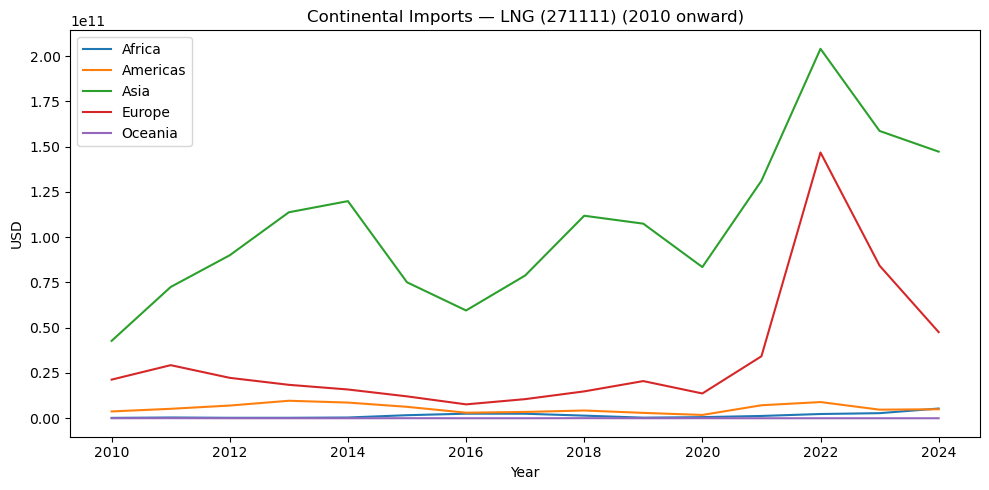

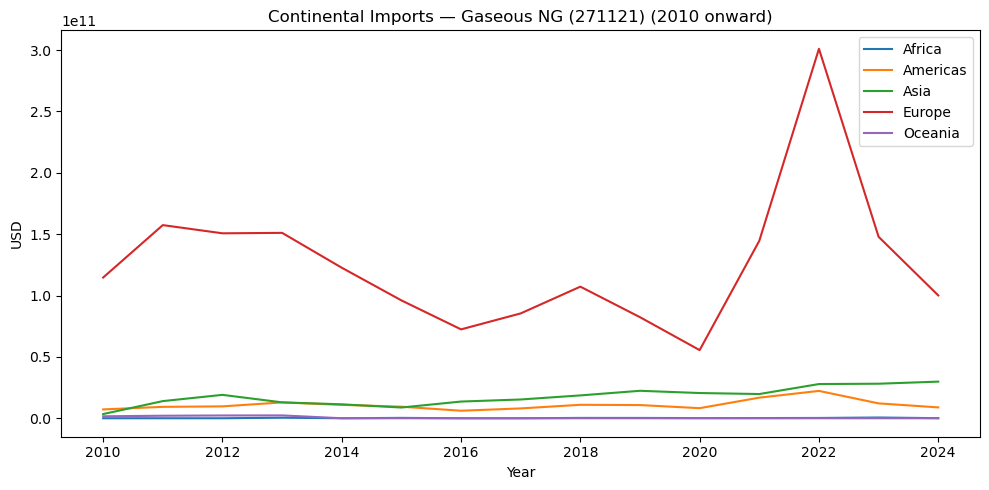

In [12]:
annual_cont = (
    df_2010
    .groupby(["refYear", "continent", "flow", "product"], as_index=False)
    .agg(value_usd=("primaryValue", "sum"))
)

annual_cont.head()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plt.figure(figsize=(10,5))
    tmp = annual_cont[
        (annual_cont["product"] == prod) &
        (annual_cont["flow"] == "Import")
    ]

    for cont in sorted(tmp["continent"].unique()):
        sub = tmp[tmp["continent"] == cont].sort_values("refYear")
        plt.plot(sub["refYear"], sub["value_usd"], label=cont)

    plt.title(f"Continental Imports — {prod} (2010 onward)")
    plt.xlabel("Year")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()





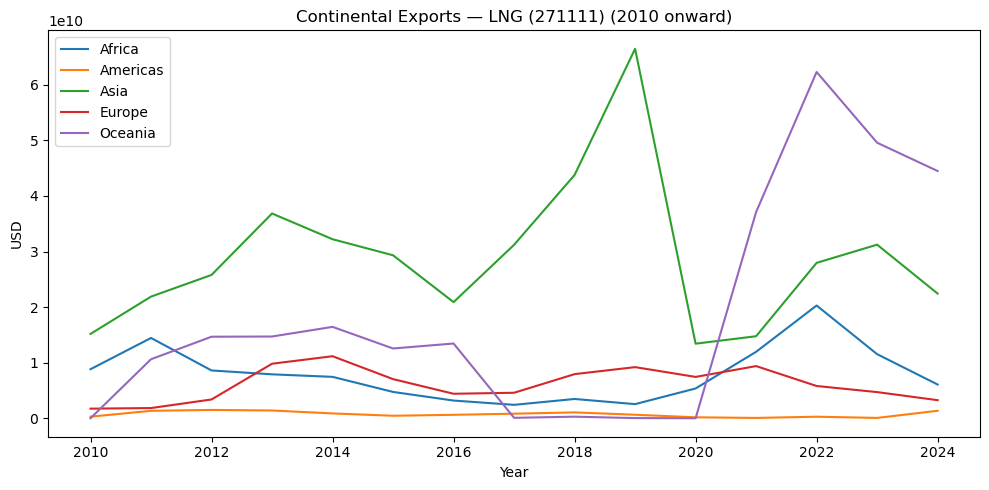

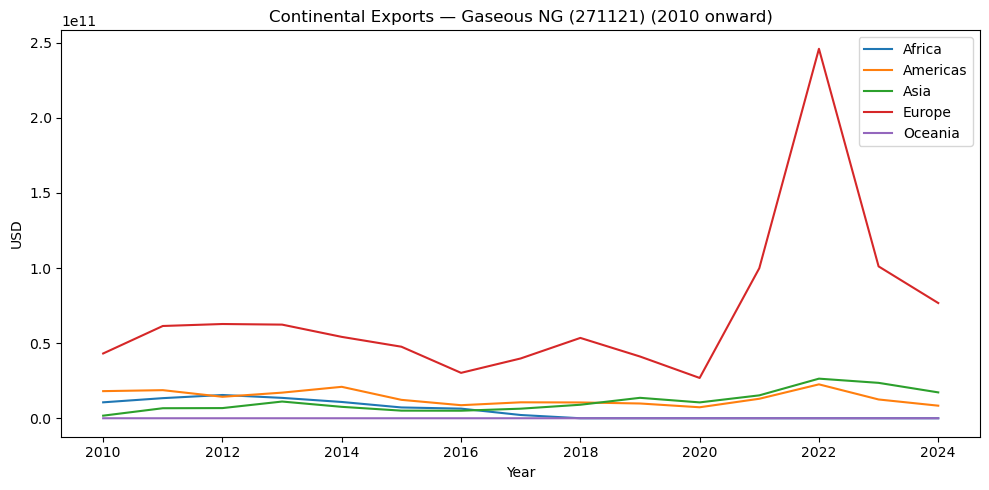

In [13]:
# Same but for export
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plt.figure(figsize=(10,5))
    tmp = annual_cont[
        (annual_cont["product"] == prod) &
        (annual_cont["flow"] == "Export")
    ]

    for cont in sorted(tmp["continent"].unique()):
        sub = tmp[tmp["continent"] == cont].sort_values("refYear")
        plt.plot(sub["refYear"], sub["value_usd"], label=cont)

    plt.title(f"Continental Exports — {prod} (2010 onward)")
    plt.xlabel("Year")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()


Please find explanations of the above plot:

1 - LNG import values increase steadily over time, with Asia and Europe emerging as the dominant importing regions. A pronounced spike in European LNG imports in 2022 reflects crisis-driven substitution away from pipeline gas combined with extreme global price increases.

2 - Pipeline natural gas imports are concentrated in Europe throughout the sample period. There is a sharp increase in 2022, followed by a rapid decline, indicating a price-driven shock and subsequent disruption of pipeline-based supply.

Note: Continental import values represent aggregated customs-reported trade flows and should be interpreted as indicators of trade intensity rather than net regional gas expenditure.


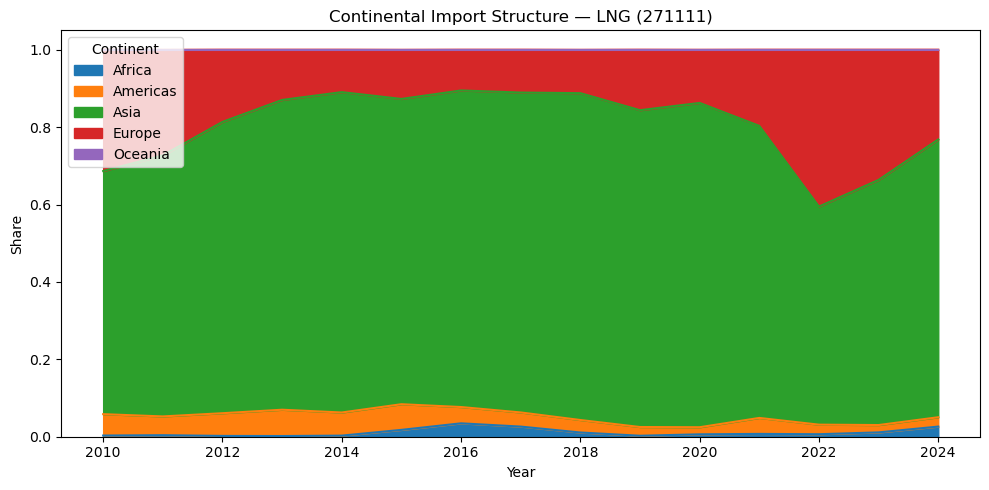

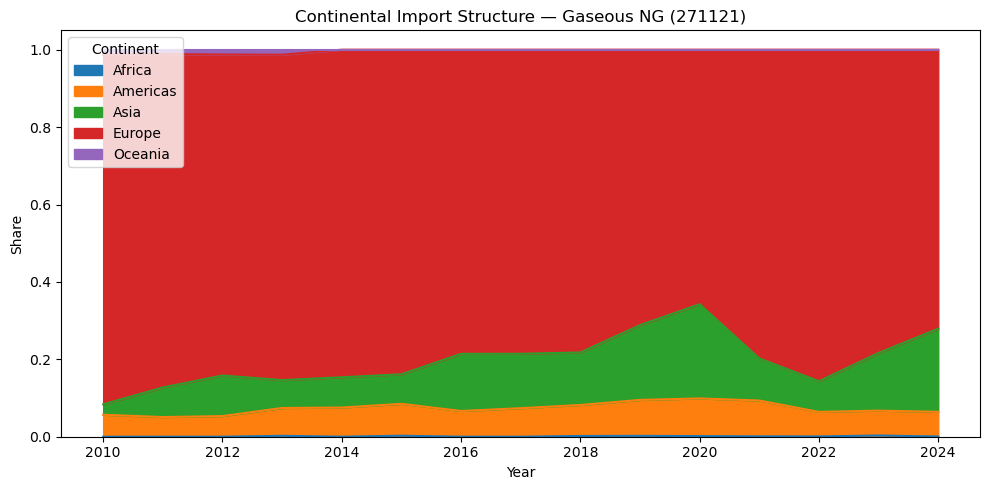

In [14]:
# Continental Import Shares

cont_imports = annual_cont[annual_cont["flow"] == "Import"].copy()

cont_imports["total_value"] = (
    cont_imports
    .groupby(["refYear", "product"])["value_usd"]
    .transform("sum")
)

cont_imports["share"] = cont_imports["value_usd"] / cont_imports["total_value"]

cont_imports.head()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = (
        cont_imports[cont_imports["product"] == prod]
        .pivot(index="refYear", columns="continent", values="share")
        .fillna(0)
        .sort_index()
    )

    tmp.plot.area(figsize=(10,5))
    plt.title(f"Continental Import Structure — {prod}")
    plt.xlabel("Year")
    plt.ylabel("Share")
    plt.legend(title="Continent", loc="upper left")
    plt.tight_layout()
    plt.show()





Please find the explantionof the above plots:
    We see that Europe has dominated the Gaseous NG market, while Asia was primarily dependednt on LNG. But in 2022 we notice, due to the Russia-Ukraine war and disruption in pipeline supply, there is a signifincat share of Europe in the LNG market

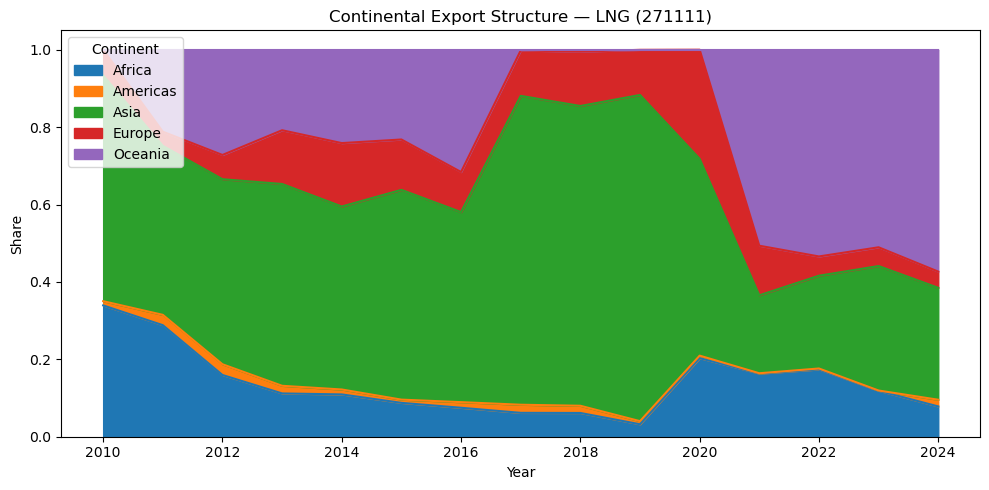

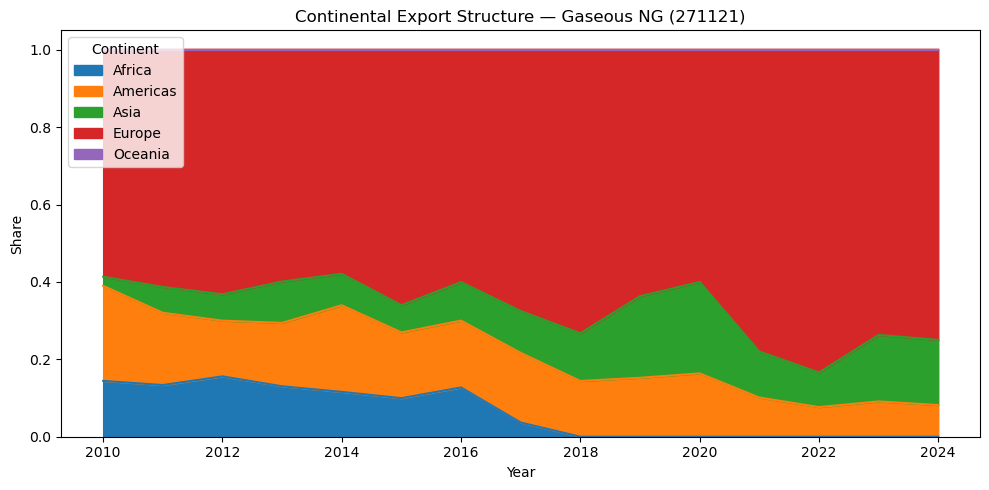

In [15]:
# Continental Export Shares

cont_imports = annual_cont[annual_cont["flow"] == "Export"].copy()

cont_imports["total_value"] = (
    cont_imports
    .groupby(["refYear", "product"])["value_usd"]
    .transform("sum")
)

cont_imports["share"] = cont_imports["value_usd"] / cont_imports["total_value"]

# cont_imports.head()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = (
        cont_imports[cont_imports["product"] == prod]
        .pivot(index="refYear", columns="continent", values="share")
        .fillna(0)
        .sort_index()
    )

    tmp.plot.area(figsize=(10,5))
    plt.title(f"Continental Export Structure — {prod}")
    plt.xlabel("Year")
    plt.ylabel("Share")
    plt.legend(title="Continent", loc="upper left")
    plt.tight_layout()
    plt.show()



Please find explanations of above plot:
    We see Ocenia, driven by Australia being one of the largest exporters of LNG has grown drastically over the several years. While Europe domiantes in gaseous ng market due to interconnected netweorks




In [16]:
# Country level analysis next

annual_country = (
    df_2010
    .groupby(
        ["refYear", "product", "flow", "reporterCode", "reporter"],
        as_index=False
    )
    .agg(value_usd=("primaryValue", "sum"))
)

annual_country.head()




,refYear,product,flow,reporterCode,reporter,value_usd
0,2010,Gaseous NG (271121),Export,12,Algeria,1.059942e+10
1,2010,Gaseous NG (271121),Export,32,Argentina,2.158250e+08
2,2010,Gaseous NG (271121),Export,36,Australia,2.768795e+04
3,2010,Gaseous NG (271121),Export,51,Armenia,1.410111e+07
4,2010,Gaseous NG (271121),Export,56,Belgium,6.209023e+09


In [17]:
# Function to check top countries for both imports and exports (LNG)
def top_countries(
    df,
    year,
    product,
    flow=None,     
    n=20
):
    tmp = df[
        (df["refYear"] == year) &
        (df["product"] == product)
    ].copy()

    if flow is not None:
        tmp = tmp[tmp["flow"] == flow]

    tmp = tmp.sort_values("value_usd", ascending=False)
    tmp = tmp.head(n).copy()
    tmp["rank"] = range(1, len(tmp) + 1)

    cols = ["rank", "reporter", "flow", "value_usd"]
    return tmp[cols]


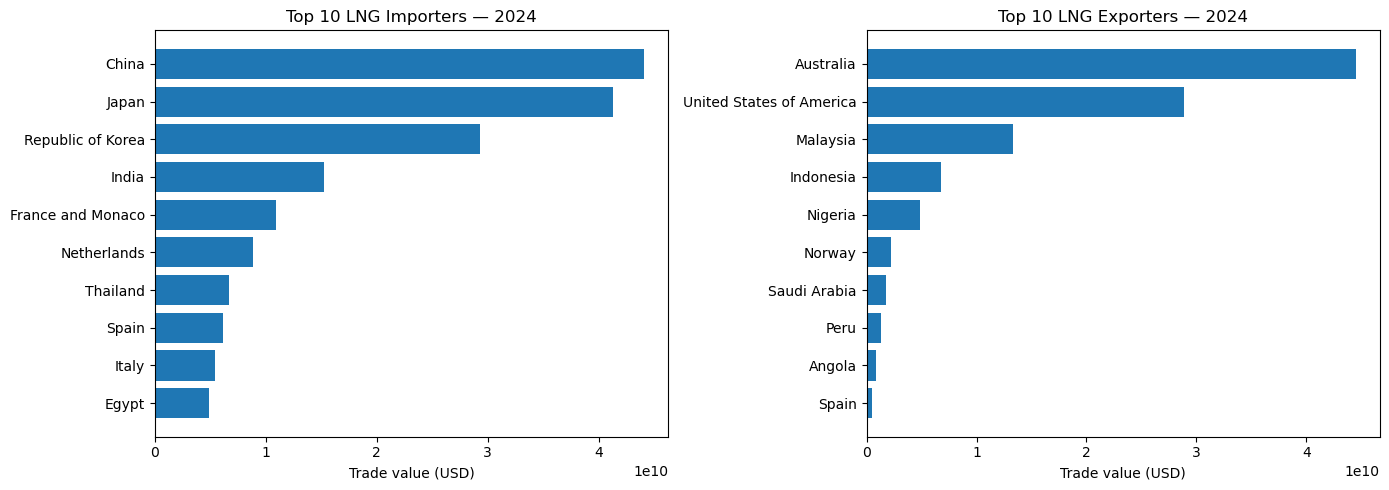

In [18]:
# Top LNG exporters and importers per year, please change the year so that it can reflect the results
year = 2024
N = 10
product = "LNG (271111)"

top_lng_imp = top_countries(
    annual_country,
    year=year,
    product=product,
    flow="Import",
    n=N
)

top_lng_exp = top_countries(
    annual_country,
    year=year,
    product=product,
    flow="Export",
    n=N
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

# IMPORTS
axes[0].barh(
    top_lng_imp["reporter"].iloc[::-1],
    top_lng_imp["value_usd"].iloc[::-1]
)
axes[0].set_title(f"Top {N} LNG Importers — {year}")
axes[0].set_xlabel("Trade value (USD)")

# EXPORTS
axes[1].barh(
    top_lng_exp["reporter"].iloc[::-1],
    top_lng_exp["value_usd"].iloc[::-1]
)
axes[1].set_title(f"Top {N} LNG Exporters — {year}")
axes[1].set_xlabel("Trade value (USD)")

plt.tight_layout()
plt.show()


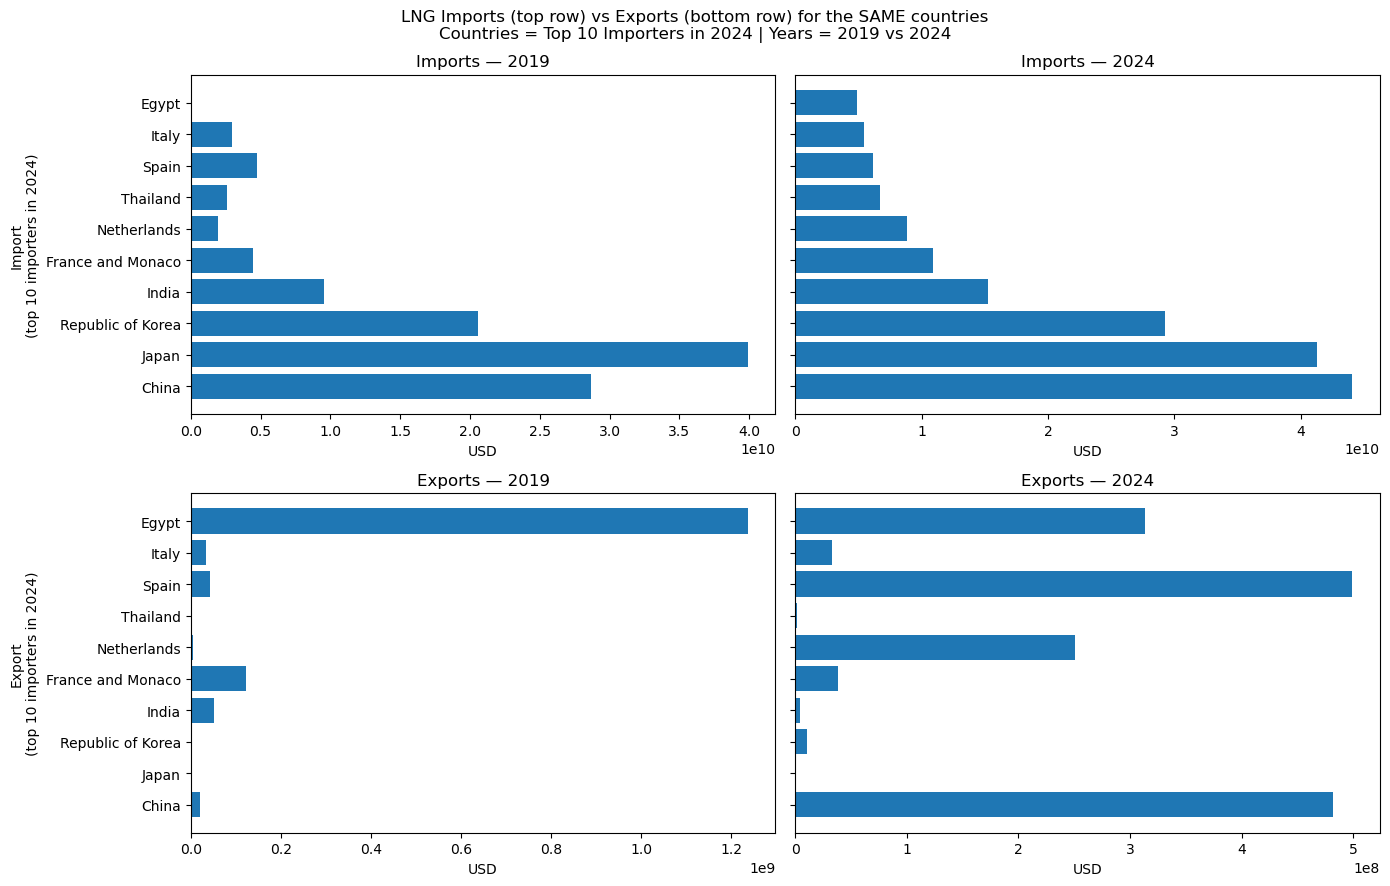

In [ ]:
ref_year = 2024
compare_years = [2019, 2024]
N = 10
product = "LNG (271111)"

# Define the shared country list from top IMPORTERS in ref_year
ref_tbl = top_countries(
    annual_country,
    year=ref_year,
    product=product,
    flow="Import",
    n=N
)
order = ref_tbl.sort_values("rank")["reporter"].tolist()

fig, axes = plt.subplots(
    nrows=2, ncols=len(compare_years),
    figsize=(14, 9),
    sharey=True
)

for r, flow in enumerate(["Import", "Export"]):
    #  Pull data for  years for this flow, but only for the shared order
    sub = annual_country[
        (annual_country["refYear"].isin(compare_years)) &
        (annual_country["product"] == product) &
        (annual_country["flow"] == flow) &
        (annual_country["reporter"].isin(order))
    ][["refYear", "reporter", "value_usd"]].copy()

    # Build a complet grid (all reporters × all years) and fill missing with 0
    grid = (
        pd.MultiIndex.from_product([compare_years, order], names=["refYear", "reporter"])
        .to_frame(index=False)
        .merge(sub, on=["refYear", "reporter"], how="left")
    )
    grid["value_usd"] = grid["value_usd"].fillna(0)

    grid["reporter"] = pd.Categorical(grid["reporter"], categories=order, ordered=True)

    # Plot each year as a column
    for c, y in enumerate(compare_years):
        ax = axes[r, c]
        tmp = grid[grid["refYear"] == y].sort_values("reporter")

        ax.barh(tmp["reporter"], tmp["value_usd"])
        ax.set_title(f"{flow}s — {y}")
        ax.set_xlabel("USD")
        if c == 0:
            ax.set_ylabel(f"{flow}\n(top {N} importers in {ref_year})")

plt.suptitle(
    f"LNG Imports (top row) vs Exports (bottom row) for the SAME countries\n"
    f"Countries = Top {N} Importers in {ref_year} | Years = {compare_years[0]} vs {compare_years[1]}",
    y=0.98
)
plt.tight_layout()
plt.show()
